In [43]:
from newGeo.dtGeometry import *
from itertools import chain
import logging
# MAPPING DIGIS
def create_wire_position_mapping(df_geometry):
    """
    Creates a mapping from (chamber_rawId, superLayerNumber, layerNumber, wire_number)
    to (x_position, y_position) for all wires in the geometry dataframe.

    Parameters:
        df_geometry (pd.DataFrame): DataFrame with geometry data.

    Returns:
        dict: Mapping from (chamber_rawId, superLayerNumber, layerNumber, wire_number)
              to (x, y) position of each wire.
    """
    mapping = {}

    for idx, row in df_geometry.iterrows():
        chamber_rawId = row['Chamber_rawId']
        superLayerNumber = row['SuperLayerNumber']
        layerNumber = row['LayerNumber']
        channels_first = int(row['Channels_first'])
        channels_last = int(row['Channels_last'])
        channels_total = channels_last - channels_first + 1
        wireFirst = float(row['WirePositions_FirstWire'])
        wireLast = float(row['WirePositions_LastWire'])
        layer_y = float(row['Layer_Local_z'])

        # Create Wire object
        wire_obj = Wire(wireFirst, wireLast, channels_total, layer_y)

        # Map wire numbers (actual channel IDs) to positions
        for i, x_pos in enumerate(wire_obj.positions):
            wire_number = channels_first + i  # Actual channel ID
            key = (chamber_rawId, superLayerNumber, layerNumber, wire_number)
            mapping[key] = (x_pos, wire_obj.layer_y)

    return mapping

def explode_dataframe(df, list_columns):
    """Explota columnas con listas en filas separadas."""
    # Repetir indices segun la longitud de las listas
    lengths = df[list_columns[0]].apply(len)
    idx = df.index.repeat(lengths)

    # Explotar las columnas de listas
    exploded_data = {col: list(chain.from_iterable(df[col])) for col in list_columns}

    # Agregar las columnas que no son listas
    exploded_df = pd.DataFrame(exploded_data, index=idx)
    non_list_columns = df.columns.difference(list_columns)
    for col in non_list_columns:
        exploded_df[col] = df[col].repeat(lengths)

    return exploded_df.reset_index(drop=True)

def add_chamber_rawId_to_digis(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['digi_wheel'], row['digi_station'], row['digi_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['digi_chamber_rawId'] = chamber_rawIds
    return df

def map_digi_wires_to_positions(df, wire_position_mapping):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    y_positions = []
    for idx, row in df.iterrows():
        key = (row['digi_chamber_rawId'], row['digi_superLayer'], row['digi_layer'], row['digi_wire'])
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        if x_pos is not None:
            x_positions.append(x_pos[0])
            y_positions.append(x_pos[1])
        else:
            #Print why the mapping failed
            logging.warning(f"Mapping failed for key: {key}")
            x_positions.append(None)
            y_positions.append(None)
    logging.warning(f"Missing mapping for key: {key}")

        
    df['digi_x_pos'] = x_positions
    df['digi_y_pos'] = y_positions
    return df

def reconstruct_dataframe(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    df_flattened["original_index"] = df_original.index.repeat(
        df_original[list_columns[0]].apply(len)
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# MAPPING SEGMENTS
def add_chamber_rawId_to_segments(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['seg_wheel'], row['seg_station'], row['seg_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['seg_chamber_rawId'] = chamber_rawIds
    return df

def map_segments_wires_to_positions(df, wire_position_mapping):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    for idx, row in df.iterrows():
        key = (row['seg_chamber_rawId'], row['seg_phiHits_superLayer'], row['seg_phiHits_layer'], row['seg_phiHits_wire'])  
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        x_positions.append(x_pos)
    df['seg_x_pos'] = x_positions
    return df

def reconstruct_dataframe_seg(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    # Ajustar índice según las filas ya existentes en df_flattened
    df_flattened["original_index"] = df_original.index.repeat(
    df_original[list_columns_2[0]].apply(lambda x: sum(len(inner_list) for inner_list in x))
    )


    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# RESTO DE DEFS

def convertir_a_lista(x):
    # Funcion para convertir Awkward Arrays a listas de Python
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]  # En caso de que sea un valor escalar, lo convertimos en lista

In [44]:
import ROOT
import pandas as pd

# Definir la ruta del archivo ROOT y el nombre del arbol
#DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0 (grande)
#DTDPGNtuple_12_4_2_Phase2Concentrator_Simulation_89
ruta_archivo_root = '../dtTuples/DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0.root'
nombre_arbol = 'dtNtupleProducer/DTTREE'

# Abrir el archivo ROOT
archivo = ROOT.TFile.Open(ruta_archivo_root)
if not archivo or archivo.IsZombie():
    raise FileNotFoundError(f"No se pudo abrir el archivo ROOT en {ruta_archivo_root}")

# Obtener el arbol
arbol = archivo.Get(nombre_arbol)
if not arbol:
    raise ValueError(f"No se encontro el arbol '{nombre_arbol}' en el archivo ROOT.")

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")


# Listas de ramas
ramas_event = ['event_eventNumber']
ramas_digis_numericas = ["digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time"]
ramas_seg_numericas = [
    "seg_wheel", "seg_sector", "seg_station", "seg_hasPhi", 
    "seg_hasZed", "seg_posLoc_x", "seg_posLoc_y", "seg_posLoc_z", 
    "seg_dirLoc_x", "seg_dirLoc_y", "seg_dirLoc_z", "seg_posLoc_x_SL1", 
    "seg_posLoc_x_SL3", "seg_posLoc_x_midPlane", "seg_posGlb_phi", 
    "seg_posGlb_eta", "seg_dirGlb_phi", "seg_dirGlb_eta", "seg_phi_t0", 
    "seg_phi_vDrift", "seg_phi_normChi2", "seg_phi_nHits", 
    "seg_z_normChi2", "seg_z_nHits"
]
ramas_seg_arrays = [
    'seg_phiHits_pos', 'seg_phiHits_posCh', 'seg_phiHits_posErr', 
    'seg_phiHits_side', 'seg_phiHits_wire', 'seg_phiHits_wirePos', 
    'seg_phiHits_layer', 'seg_phiHits_superLayer', 'seg_phiHits_time', 
    'seg_phiHits_timeCali','seg_nSegments'
]

ramas_a_extraer = ramas_event + ramas_digis_numericas + ramas_seg_numericas + ramas_seg_arrays

# Inicializar diccionario para almacenar los datos
data = {rama: [] for rama in ramas_a_extraer}

from collections import defaultdict
import time

data = defaultdict(list)
min_eventos = 0
max_eventos = 2000
start_total = time.time()

# Iterar sobre las entradas del arbol
for i, evento in enumerate(arbol):
    if i<= min_eventos:
        continue
    if i >= max_eventos:
        break  
    for rama in ramas_a_extraer:
        valor = getattr(evento, rama, None)
        
        if valor is None:
            data[rama].append(None)
            continue

        # Optimizacion: manejar TClonesArray
        if hasattr(valor, 'GetEntriesFast'):
            n_entries = valor.GetEntriesFast()  # Guardar numero de entradas
            valores = [
                [x for x in valor.At(i)] if hasattr(valor.At(i), '__len__') else valor.At(i)
                for i in range(n_entries)
            ]
            data[rama].append(valores)
        elif isinstance(valor, (ROOT.TVectorF, ROOT.TVectorD)):
            # Optimizacion: convertir directamente a lista
            data[rama].append(list(valor))
        elif isinstance(valor, (int, float)):
            # Escalar simple
            data[rama].append(valor)
        else:
            try:
                # Intentar convertir a lista si es iterable
                data[rama].append(list(valor))
            except TypeError:
                data[rama].append(valor)
    
    if i%10000==0:
        print(f"Evento {i+1}")

end_total = time.time()
print(f"Tiempo total: {end_total - start_total:.2f} segundos")
# Cerrar el archivo ROOT
archivo.Close()

# Verificar que todas las ramas tienen la misma longitud
longitudes = {rama: len(val) for rama, val in data.items()}
print("Longitud de cada rama:")

for rama, longitud in longitudes.items():
    print(f"{rama}: {longitud}")

# Convertir a DataFrame
try:
    df = pd.DataFrame(data)
except ValueError as e:
    print("Error al crear el DataFrame:", e)
    for rama, longitud in longitudes.items():
        print(f"{rama}: {longitud}")
    raise

# Mostrar una vista previa del DataFrame
print("\nVista previa del DataFrame:")
df.head()

# Contar los hits en las ramas tipo array
for rama in ramas_seg_arrays:
    if rama in df.columns:
        df[f'{rama}_count'] = df[rama].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Mostrar conteos
for rama in ramas_seg_arrays:
    if f'{rama}_count' in df.columns:
        print(f"\nNumero de hits por evento en '{rama}':")
        print(df[f'{rama}_count'].head())



El arbol tiene 933000 eventos.
Tiempo total: 3.46 segundos
Longitud de cada rama:
event_eventNumber: 1999
digi_nDigis: 1999
digi_wheel: 1999
digi_sector: 1999
digi_station: 1999
digi_superLayer: 1999
digi_layer: 1999
digi_wire: 1999
digi_time: 1999
seg_wheel: 1999
seg_sector: 1999
seg_station: 1999
seg_hasPhi: 1999
seg_hasZed: 1999
seg_posLoc_x: 1999
seg_posLoc_y: 1999
seg_posLoc_z: 1999
seg_dirLoc_x: 1999
seg_dirLoc_y: 1999
seg_dirLoc_z: 1999
seg_posLoc_x_SL1: 1999
seg_posLoc_x_SL3: 1999
seg_posLoc_x_midPlane: 1999
seg_posGlb_phi: 1999
seg_posGlb_eta: 1999
seg_dirGlb_phi: 1999
seg_dirGlb_eta: 1999
seg_phi_t0: 1999
seg_phi_vDrift: 1999
seg_phi_normChi2: 1999
seg_phi_nHits: 1999
seg_z_normChi2: 1999
seg_z_nHits: 1999
seg_phiHits_pos: 1999
seg_phiHits_posCh: 1999
seg_phiHits_posErr: 1999
seg_phiHits_side: 1999
seg_phiHits_wire: 1999
seg_phiHits_wirePos: 1999
seg_phiHits_layer: 1999
seg_phiHits_superLayer: 1999
seg_phiHits_time: 1999
seg_phiHits_timeCali: 1999
seg_nSegments: 1999

Vista p

In [45]:
import pandas as pd

# --------------------------------------
# Función auxiliar para contar cuántos '1' hay en seg_hasPhi
# --------------------------------------
def sum_seg_hasPhi(series_of_lists):
    """
    Dada una Serie donde cada elemento es una lista de 0s y 1s,
    cuenta el número total de 1s en todas las listas de la Serie.
    """
    total = 0
    for item in series_of_lists:
        if isinstance(item, list):
            total += sum(item)
        elif pd.notnull(item):
            total += item  # puede ser un int o float individual
    return total

# --------------------------------------
# 1) Crear el DataFrame con sólo los digis
# --------------------------------------
digi_cols = [
    "event_eventNumber",
    "digi_nDigis",
    "digi_wheel",
    "digi_sector",
    "digi_station",
    "digi_superLayer",
    "digi_layer",
    "digi_wire",
    "digi_time",
]
df_digi = df[digi_cols].copy()

# Expandimos las listas para obtener un digi por fila
digi_cols_to_explode = [
    "digi_wheel",
    "digi_sector",
    "digi_station",
    "digi_superLayer",
    "digi_layer",
    "digi_wire",
    "digi_time"
]
df_digi_exploded = df_digi.explode(digi_cols_to_explode).reset_index(drop=True)

# Filtramos los digis de superLayer 2
df_digi_exploded = df_digi_exploded[df_digi_exploded["digi_superLayer"] != 2]
df_digi_exploded.reset_index(drop=True, inplace=True)

print("Digi exploded columns:\n", df_digi_exploded.columns)
print(f"df_digi_exploded shape: {df_digi_exploded.shape}")

# --------------------------------------
# 2) Cargar geometría y mapear posiciones
# --------------------------------------
geometry_xml_path = "newGeo/DTGeometry.xml"
print("\nParsing DT Geometry XML...")

df_geometry = parse_dtgeometry_xml(geometry_xml_path)
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Añadir identificador de cámara
df_flattened = add_chamber_rawId_to_digis(df_digi_exploded)

df_test = df_flattened.copy()

# Mapear posiciones físicas de los wires
df_flattened = map_digi_wires_to_positions(df_flattened, wire_position_mapping)

# --------------------------------------
# 3) Crear DataFrame sólo con segmentos
# --------------------------------------
seg_cols = [
    "event_eventNumber",
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_phi_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    "seg_phiHits_side",
    "seg_phiHits_wirePos",
    "seg_phiHits_time",
]
df_seg = df[seg_cols].copy()

# Contar cuántos segmentos phi hay por evento
df_phiCounts = (
    df_seg
    .groupby("event_eventNumber")["seg_hasPhi"]
    .agg(sum_seg_hasPhi)
    .reset_index(name="num_phi_segments_event")
)

# Añadir columna con el número de segmentos phi por evento
df_seg = pd.merge(df_seg, df_phiCounts, on="event_eventNumber", how="left")

# --------------------------------------
# 4) Primera explosión del DataFrame de segmentos
# --------------------------------------
# Se genera una fila por segmento
seg_cols_to_explode_stage1 = [
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_phi_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    "seg_phiHits_side",
    "seg_phiHits_wirePos",
    "seg_phiHits_time",
]
df_seg_expl_1 = df_seg.explode(seg_cols_to_explode_stage1).reset_index(drop=True)

# Calcular número de segmentos phi por estación (wheel, sector, station)
df_phiCounts_station = (
    df_seg_expl_1
    .groupby(["event_eventNumber", "seg_wheel", "seg_sector", "seg_station"])["seg_hasPhi"]
    .sum()
    .reset_index(name="num_phi_segments_station")
)

# Añadir esta información al DataFrame de segmentos explotado
df_seg_expl_1 = pd.merge(
    df_seg_expl_1,
    df_phiCounts_station,
    on=["event_eventNumber", "seg_wheel", "seg_sector", "seg_station"],
    how="left"
)

# Asignar un índice único por segmento dentro de la estación
df_seg_expl_1["segmentIndexStation"] = (
    df_seg_expl_1
    .groupby(["event_eventNumber", "seg_wheel", "seg_sector", "seg_station"])
    .cumcount()
)

# Asignar un índice único por segmento dentro del evento
df_seg_expl_1["segmentIndexEvent"] = (
    df_seg_expl_1
    .groupby(["event_eventNumber"])
    .cumcount()
)

# --------------------------------------
# 5) Segunda explosión del DataFrame de segmentos por hit
# --------------------------------------
df_segHits_exploded = df_seg_expl_1.explode([
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    "seg_phiHits_side",
    "seg_phiHits_wirePos",
    "seg_phiHits_time"
]).reset_index(drop=True)

print("Segment exploded columns:\n", df_segHits_exploded.columns)
print(f"df_segHits_exploded shape: {df_segHits_exploded.shape}")

# --------------------------------------
# 6) Merge entre digis y segmentos para etiquetado
# --------------------------------------
df_merged = pd.merge(
    left=df_flattened,
    right=df_segHits_exploded,
    how="left",
    left_on=[
        "event_eventNumber",
        "digi_wheel",
        "digi_sector",
        "digi_station",
        "digi_superLayer",
        "digi_layer",
        "digi_wire"
    ],
    right_on=[
        "event_eventNumber",
        "seg_wheel",
        "seg_sector",
        "seg_station",
        "seg_phiHits_superLayer",
        "seg_phiHits_layer",
        "seg_phiHits_wire"
    ]
)

# Etiquetas: 1 si pertenece a un segmento (por estación o por evento)
df_merged["label_station"] = df_merged["segmentIndexStation"].notnull().astype(int)
df_merged["label_event"] = df_merged["segmentIndexEvent"].notnull().astype(int)

# --------------------------------------
# 7) Agrupar por digi para consolidar índices de segmentos
# --------------------------------------
grp_cols = [
    "event_eventNumber",
    "digi_wheel",
    "digi_sector",
    "digi_station",
    "digi_superLayer",
    "digi_layer",
    "digi_wire",
    "digi_time",
    "digi_x_pos",
    "digi_y_pos",
    "num_phi_segments_station",
    "num_phi_segments_event",
]

df_simplified = (
    df_merged
    .groupby(grp_cols, dropna=False)
    .agg({
        "segmentIndexStation": lambda x: sorted(list(x.dropna().unique().astype(int))),
        "label_station": "max",
        "segmentIndexEvent": lambda x: sorted(list(x.dropna().unique().astype(int))), 
        "label_event": "max"
    })
    .reset_index()
)

# Convertir índices a enteros (por compatibilidad)
df_simplified["segmentIndexStation"] = df_simplified["segmentIndexStation"].apply(
    lambda segs: [int(s) for s in segs]
)
df_simplified["segmentIndexEvent"] = df_simplified["segmentIndexEvent"].apply(
    lambda segs: [int(s) for s in segs]
)

# Etiquetas adicionales: 1 si pertenece a más de un segmento
df_simplified["multiSegLabelStation"] = df_simplified["segmentIndexStation"].apply(
    lambda segs: 1 if len(segs) > 1 else 0
)
df_simplified["multiSegLabelEvent"] = df_simplified["segmentIndexEvent"].apply(
    lambda segs: 1 if len(segs) > 1 else 0
)

# --------------------------------------
# 8) Propagación de valores faltantes (NaNs)
# --------------------------------------
group_keys_station = ["event_eventNumber", "digi_wheel", "digi_sector", "digi_station"]
group_keys_event = ["event_eventNumber"]

# Rellenar num_phi_segments_event
df_simplified["num_phi_segments_event"] = df_simplified.groupby(group_keys_event)["num_phi_segments_event"] \
    .transform(lambda x: x.fillna(x.max()))

# Rellenar num_phi_segments_station con 0 si no hay ningún segmento
df_simplified["num_phi_segments_station"] = df_simplified.groupby(group_keys_station)["num_phi_segments_station"] \
    .transform(lambda x: x.fillna(x.max() if pd.notnull(x.max()) else 0))


Digi exploded columns:
 Index(['event_eventNumber', 'digi_nDigis', 'digi_wheel', 'digi_sector',
       'digi_station', 'digi_superLayer', 'digi_layer', 'digi_wire',
       'digi_time'],
      dtype='object')
df_digi_exploded shape: (79487, 9)

Parsing DT Geometry XML...


Segment exploded columns:
 Index(['event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station',
       'seg_hasPhi', 'seg_phi_nHits', 'seg_phiHits_wire', 'seg_phiHits_layer',
       'seg_phiHits_superLayer', 'seg_phiHits_side', 'seg_phiHits_wirePos',
       'seg_phiHits_time', 'num_phi_segments_event',
       'num_phi_segments_station', 'segmentIndexStation', 'segmentIndexEvent'],
      dtype='object')
df_segHits_exploded shape: (57171, 16)


In [46]:
##############################################
# 6) Generar columnas one-hot para la pertenencia a segmentos
##############################################
def one_hot_vector(segment_list, total_segments):
    """
    Dada una lista de índices de segmentos (segment_list) y el número total de segmentos (total_segments),
    retorna un vector one-hot (lista) de longitud total_segments:
      - Si el dígito pertenece a determinados segmentos, esas posiciones serán 1.
      - Si es ruido (lista vacía), retorna un vector de ceros de longitud total_segments.
    """
    if pd.isnull(total_segments) or (total_segments == 0):
        return [0]
    total_segments = int(total_segments)
    if not (isinstance(segment_list, list) and len(segment_list) > 0):
        return [0] * total_segments
    onehot = [0] * total_segments
    for idx in segment_list:
        try:
            idx_int = int(idx)
            if 0 <= idx_int < total_segments:
                onehot[idx_int] = 1
        except Exception:
            continue
    return onehot

# Generar one-hot a nivel de evento
df_simplified["onehot_event"] = df_simplified.apply(
    lambda row: one_hot_vector(row["segmentIndexEvent"], row["num_phi_segments_event"]),
    axis=1
)

# Generar one-hot a nivel de estación
df_simplified["onehot_station"] = df_simplified.apply(
    lambda row: one_hot_vector(row["segmentIndexStation"], row["num_phi_segments_station"]),
    axis=1
)

##############################################
# Mostrar resultados de ejemplo
##############################################
cols_ver = [
    "event_eventNumber", "digi_wheel", "digi_sector", "digi_station", 
    "segmentIndexEvent", "num_phi_segments_event", "onehot_event",
    "segmentIndexStation", "num_phi_segments_station", "onehot_station",
    "multiSegLabelEvent", "multiSegLabelStation", "label_event", "label_station"
]
print("Ejemplo de df_simplified final:")
df_simplified[cols_ver].head()

Ejemplo de df_simplified final:


,event_eventNumber,digi_wheel,digi_sector,digi_station,segmentIndexEvent,num_phi_segments_event,onehot_event,segmentIndexStation,num_phi_segments_station,onehot_station,multiSegLabelEvent,multiSegLabelStation,label_event,label_station
0,27001,-2,2,1,[],5.0,"[0, 0, 0, 0, 0]",[],0.0,[0],0,0,0,0
1,27001,-2,2,2,[],5.0,"[0, 0, 0, 0, 0]",[],0.0,[0],0,0,0,0
2,27001,-2,3,1,[],5.0,"[0, 0, 0, 0, 0]",[],0.0,[0],0,0,0,0
3,27001,-2,3,1,[],5.0,"[0, 0, 0, 0, 0]",[],0.0,[0],0,0,0,0
4,27001,-2,3,1,[],5.0,"[0, 0, 0, 0, 0]",[],0.0,[0],0,0,0,0


In [47]:
#REVISAR PORQUE NO FUNCIONA
import numpy as np
import pandas as pd

def generate_adaptive_noise_with_segments(
    df_all,
    noise_fraction=0.2,
    random_seed=42,
    max_new_noise_per_group=10
):
    """
    Similar to 'generate_adaptive_noise', but also carries over
    'num_phi_segments_station' and 'num_phi_segments_event' columns 
    from the group so that newly added noise matches the original group's values.

    Args:
      df_all (DataFrame): Original DataFrame of digis.
      noise_fraction (float): Proportion of new noise relative to the existing
                              total number of digis in each group.
      random_seed (int): Random seed for reproducibility.
      max_new_noise_per_group (int): Cap on how many new noise digis to add per group.

    Returns:
      A new DataFrame with added rows representing noise digis.
    """
    np.random.seed(random_seed)

    group_cols = ["event_eventNumber", "digi_wheel", "digi_sector", "digi_station"]
    df_augmented = df_all.copy()

    grouped = df_augmented.groupby(group_cols)

    new_rows = []

    for group_keys, group_df in grouped:
        n_existing = len(group_df)
        n_noise = int(n_existing * noise_fraction)
        n_noise = min(n_noise, max_new_noise_per_group)
        if n_noise == 0:
            continue

        # ---------------------------------------------------------------------
        # 1) Retrieve the group's num_phi_segments_station/num_phi_segments_event
        #    We assume they are the same across all rows in the group. 
        #    If for any reason they aren't, you might need extra logic here.
        # ---------------------------------------------------------------------
        # If the group truly has a single consistent value, 
        # group_df[column].unique() should be a 1-element array.
        val_num_phi_segments_station = int(group_df["num_phi_segments_station"].unique()[0])
        val_num_phi_segments_event   = int(group_df["num_phi_segments_event"].unique()[0])

        # ---------------------------------------------------------------------
        # 2) Pull out local min and max from the group for wire, x, y, time
        # ---------------------------------------------------------------------
        wire_min = group_df["digi_wire"].min()
        wire_max = group_df["digi_wire"].max()

        x_min = group_df["digi_x_pos"].min()
        x_max = group_df["digi_x_pos"].max()

        y_min = group_df["digi_y_pos"].min()
        y_max = group_df["digi_y_pos"].max()

        t_min = group_df["digi_time"].min()
        t_max = group_df["digi_time"].max()

        # If any range is degenerate, add a small buffer
        if wire_min == wire_max:
            wire_min -= 1
            wire_max += 1
        if x_min == x_max:
            x_min -= 1e-3
            x_max += 1e-3
        if y_min == y_max:
            y_min -= 1e-3
            y_max += 1e-3
        if t_min == t_max:
            t_min -= 1e-3
            t_max += 1e-3

        # Restrict to phi superlayers (1 and 3) if relevant
        sl_candidates = [1, 3]  
        ly_candidates = [1, 2, 3, 4]

        # ---------------------------------------------------------------------
        # 3) Generate new noise digis
        # ---------------------------------------------------------------------
        for _ in range(n_noise):
            random_sl = np.random.choice(sl_candidates)
            random_layer = np.random.choice(ly_candidates)
            random_wire = np.random.randint(wire_min, wire_max + 1)
            random_x = np.random.uniform(x_min, x_max)
            random_y = np.random.uniform(y_min, y_max)
            random_time = np.random.uniform(t_min, t_max)

            new_row = {
                "event_eventNumber": group_keys[0],
                "digi_wheel": group_keys[1],
                "digi_sector": group_keys[2],
                "digi_station": group_keys[3],
                "digi_superLayer": random_sl,
                "digi_layer": random_layer,
                "digi_wire": random_wire,
                "digi_x_pos": random_x,
                "digi_y_pos": random_y,
                "digi_time": random_time,
                "label_station": 0,  # noise
                "label_event": 0,
                "onehot_station": np.zeros(val_num_phi_segments_station, dtype=int),
                "onehot_event": np.zeros(val_num_phi_segments_event, dtype=int),
                "segmentIndexStation": [],
                "segmentIndexEvent": [],
                # Attach the group's segment info
                "num_phi_segments_station": val_num_phi_segments_station,
                "num_phi_segments_event": val_num_phi_segments_event
            }
            new_rows.append(new_row)

    # -------------------------------------------------------------------------
    # 4) Append the new noise rows to original DataFrame
    # -------------------------------------------------------------------------
    if new_rows:
        df_noise = pd.DataFrame(new_rows)
        df_augmented = pd.concat([df_augmented, df_noise], ignore_index=True)

    return df_augmented


# Generar ruido adaptativo
'''df_augmented = generate_adaptive_noise_with_segments(
    df_simplified,
    noise_fraction=0.2,
    random_seed=42,
    max_new_noise_per_group=10
)'''


'df_augmented = generate_adaptive_noise_with_segments(\n    df_simplified,\n    noise_fraction=0.2,\n    random_seed=42,\n    max_new_noise_per_group=10\n)'

In [48]:
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

def build_graph_for_chamber_event(
    df_sub,
    method="wire",
    max_intra_dist=2.1,
    max_inter_sl_dist=3.0,
    bridge_sl1_layers=None,
    bridge_sl3_layers=None,
    k_neighbors=3,
    all_wires_bridging=False,
    arc_angle_deg=0.0
):
    """
    Build adjacency for a single (event, wheel, sector, station) using:
      - 'wire' based offsets,
      - 'geometry' based thresholds in x,y,
      - 'knn' in (x,y) space.

    The adjacency is built differently depending on `method`:
      - If method='wire' or 'geometry', we connect consecutive layers 
        and optionally bridge from SL1 to SL3.
      - If method='knn', we ignore bridging logic and simply connect 
        each node to its k nearest neighbors in (x,y).

    Additional bridging parameters:
      all_wires_bridging (bool): If True, 
         for any layer in bridge_sl1_layers -> layer in bridge_sl3_layers,
         connect all nodes from SL1 to all nodes in SL3, 
         ignoring wire or geometry checks. (Still requires sy>ty if you want top->bottom.)
      arc_angle_deg (float): If > 0, 
         do an angle-based bridging for SL1->SL3. For each SL1 node, we connect 
         to SL3 nodes whose vector is within ±(arc_angle_deg/2) degrees of vertical (down).
         This logic is applied only if all_wires_bridging=False. 
         If arc_angle_deg=0, we skip this angle logic and use the default bridging rule.

    Args:
      df_sub: DataFrame with columns:
         - digi_x_pos, digi_y_pos (if using geometry or knn)
         - digi_wire, digi_layer, digi_superLayer
         - label_station (0/1) ...
      method: str, one of ["wire", "geometry", "knn"].
      max_intra_dist: used only if method='geometry'.
      max_inter_sl_dist: used only if method='geometry'.
      bridge_sl1_layers: optional list of layers in SL1 to connect to SL3. 
                         used only for 'wire'/'geometry'.
      bridge_sl3_layers: optional list of layers in SL3 to receive bridging 
                         from SL1. used only for 'wire'/'geometry'.
      k_neighbors: int, used only if method='knn'. 
                   The number of nearest neighbors to connect per node.
      all_wires_bridging: bool, if True => full bipartite bridging (SL1->SL3).
      arc_angle_deg: float, if >0 => arc bridging logic in degrees.

    Returns:
      A PyTorch Geometric Data object with:
        data.x => node features (tensor of shape [N, F])
        data.edge_index => adjacency (tensor [2, E])
        data.edge_attr  => optional edge attributes (tensor [E, 3]) 
                           (e.g. [dx, dy, dist])
        data.y => labels (tensor [N])
    """

    if bridge_sl1_layers is None:
        bridge_sl1_layers = [4]
    if bridge_sl3_layers is None:
        bridge_sl3_layers = [1]

    df_sub = df_sub.reset_index(drop=True)

    # Node features: (layer, superLayer, wire, x, y, time)
    node_feature_cols = [
        "digi_layer", 
        "digi_superLayer", 
        "digi_wire", 
        "digi_x_pos", 
        "digi_y_pos",
        "digi_time"
    ]
    for col in node_feature_cols:
        if col not in df_sub.columns:
            df_sub[col] = 0.0

    # Convert node features to torch tensor
    x_np = df_sub[node_feature_cols].to_numpy()  # shape [N, F=6]
    x = torch.tensor(x_np, dtype=torch.float)

    # Labels
    y = torch.tensor(df_sub["label_station"].values, dtype=torch.long)

    # Prepare adjacency lists
    edge_i, edge_j = [], []
    edge_attr_list = []  # each edge attribute = [dx, dy, dist]

    def add_edge(si, ti, sx, sy, tx, ty):
        """Helper to append edges i->j with edge attributes [dx, dy, dist]."""
        dx = tx - sx
        dy = ty - sy
        dist = np.hypot(dx, dy)
        edge_i.append(si)
        edge_j.append(ti)
        edge_attr_list.append([dx, dy, dist])

    # --------------------------------------------------------------------
    # 1) If method='knn', ignore bridging logic entirely
    #    and build edges by kNN in (x, y).
    # --------------------------------------------------------------------
    if method == "knn":
        coords_2d = x_np[:, [3, 4]]  # shape [N, 2] -> (x, y)
        nbrs = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='auto').fit(coords_2d)
        distances, indices = nbrs.kneighbors(coords_2d)

        N = coords_2d.shape[0]
        for i in range(N):
            sx, sy = coords_2d[i]
            # skip the first neighbor => the node itself
            neighbor_ids = indices[i, 1:]
            for j in neighbor_ids:
                tx, ty = coords_2d[j]
                add_edge(i, j, sx, sy, tx, ty)

    else:
        # --------------------------------------------------------------------
        # 2) Intra-superlayer adjacency: connect (sl, layer) -> (sl, layer+1)
        #    plus bridging from SL1->SL3 (if requested).
        # --------------------------------------------------------------------
        grouped = df_sub.groupby(["digi_superLayer", "digi_layer"])
        sl_layer_to_nodes = {}
        for (sl, layer), group_df_ in grouped:
            node_idxs = group_df_.index.to_numpy()
            wires = group_df_["digi_wire"].to_numpy()
            xs    = group_df_["digi_x_pos"].to_numpy()
            ys    = group_df_["digi_y_pos"].to_numpy()
            sl_layer_to_nodes[(sl, layer)] = (node_idxs, wires, xs, ys)

        # (a) Intra-superlayer adjacency
        for (sl, layer), (src_idxs, src_wires, src_xs, src_ys) in sl_layer_to_nodes.items():
            next_key = (sl, layer + 1)
            if next_key not in sl_layer_to_nodes:
                continue
            (tgt_idxs, tgt_wires, tgt_xs, tgt_ys) = sl_layer_to_nodes[next_key]

            for si, sw, sx, sy in zip(src_idxs, src_wires, src_xs, src_ys):
                for ti, tw, tx, ty in zip(tgt_idxs, tgt_wires, tgt_xs, tgt_ys):
                    connect = False

                    if method == "wire":
                        # Your staggered logic
                        offset = tw - sw
                        if layer == 1:
                            if offset in (0, +1):
                                connect = True
                        elif layer == 2:
                            if offset in (0, -1):
                                connect = True
                        elif layer == 3:
                            if offset in (0, +1):
                                connect = True
                    else:
                        # method == "geometry"
                        dx = tx - sx
                        dy = ty - sy
                        dist = np.hypot(dx, dy)
                        if dist <= max_intra_dist:
                            connect = True

                    if connect:
                        add_edge(si, ti, sx, sy, tx, ty)

        # (b) Inter-superlayer bridging: from SL1->SL3
        #     only if method in ['wire', 'geometry'].
        for layer_sl1 in bridge_sl1_layers:
            for layer_sl3 in bridge_sl3_layers:
                key_sl1 = (1, layer_sl1)
                key_sl3 = (3, layer_sl3)
                if key_sl1 not in sl_layer_to_nodes or key_sl3 not in sl_layer_to_nodes:
                    continue

                (src_idxs, src_wires, src_xs, src_ys) = sl_layer_to_nodes[key_sl1]
                (tgt_idxs, tgt_wires, tgt_xs, tgt_ys) = sl_layer_to_nodes[key_sl3]

                for si, sw, sx, sy in zip(src_idxs, src_wires, src_xs, src_ys):
                    for ti, tw, tx, ty in zip(tgt_idxs, tgt_wires, tgt_xs, tgt_ys):
                        connect = False

                        # Always top->bottom => sy > ty 
                        if sy <= ty:
                            continue

                        if all_wires_bridging:
                            # If user wants full bipartite bridging, connect everything
                            connect = True

                        elif arc_angle_deg > 0.0:
                            # Arc-based bridging
                            dx = tx - sx
                            dy = ty - sy
                            dist_vec = np.hypot(dx, dy)
                            if dist_vec > 0:
                                # angle wrt vertical (0, -1)
                                angle_rad = np.arccos((-dy) / dist_vec)
                                # We connect if angle is within ±(arc_angle_deg/2)
                                max_angle_rad = np.deg2rad(arc_angle_deg / 2.0)
                                if angle_rad <= max_angle_rad:
                                    connect = True

                        else:
                            # Default bridging logic
                            dx = tx - sx
                            dy = ty - sy
                            if method == "wire":
                                # bridging rule: e.g., abs(tw - sw) <= 2
                                if abs(tw - sw) <= 2:
                                    connect = True
                            else:  # method == "geometry"
                                dist = np.hypot(dx, dy)
                                if dist <= max_inter_sl_dist:
                                    connect = True

                        if connect:
                            add_edge(si, ti, sx, sy, tx, ty)

    # ------------------------------------------------------------------------
    # Build torch tensors and return final PyG Data object
    # ------------------------------------------------------------------------
    edge_index = torch.tensor([edge_i, edge_j], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float) if len(edge_attr_list) > 0 else None

    data = Data(x=x, edge_index=edge_index, y=y)
    if edge_attr is not None:
        data.edge_attr = edge_attr  # each row = [dx, dy, dist]

    return data


def build_all_graphs(df_all, method="wire", k_neighbors=3):
    """
    Build one PyG Data object per (event, wheel, sector, station),
    using the chosen adjacency method:
      - 'wire'
      - 'geometry'
      - 'knn' in (x, y)

    For 'knn', bridging logic is ignored; for 'wire'/'geometry', bridging 
    from SL1->SL3 is included.

    method: one of ["wire", "geometry", "knn"].
    k_neighbors: integer, used only if method='knn'.
    """
    data_list = []
    group_cols = ["event_eventNumber", "digi_wheel", "digi_sector", "digi_station"]

    for _, df_sub in df_all.groupby(group_cols):
        graph_data = build_graph_for_chamber_event(
            df_sub,
            method=method,
            max_intra_dist=2.1,
            max_inter_sl_dist=3.0,
            bridge_sl1_layers=None,
            bridge_sl3_layers=None,
            k_neighbors=k_neighbors,
            all_wires_bridging=True,
            arc_angle_deg=0.0
            
        )
        data_list.append(graph_data)

    return data_list


# Build graphs for all events
graphs = build_all_graphs(df_simplified, method="wire", k_neighbors=3)


In [49]:
print(f"Total graphs built: {len(graphs)}")
# Check the first graph
print("First graph data object:")
grafo = graphs[1]
print(grafo)
print("Number of nodes:", grafo.num_nodes)
print("Number of edges:", grafo.num_edges)
# Check the first graph's node features
print("Node features (x):", grafo.x)
print("Node features shape:", grafo.x.shape)
# Check the first graph's edge indices
print("Edge indices (edge_index):", grafo.edge_index)
print("Edge attributes (edge_index):", grafo.edge_attr)
print("Edge indices shape:", grafo.edge_index.shape)    


Total graphs built: 20178
First graph data object:
Data(x=[1, 6], edge_index=[2, 0], y=[1])
Number of nodes: 1
Number of edges: 0
Node features (x): tensor([[  4.0000,   1.0000,  33.0000,  12.8500,   9.8000, 540.6250]])
Node features shape: torch.Size([1, 6])
Edge indices (edge_index): tensor([], size=(2, 0), dtype=torch.int64)
Edge attributes (edge_index): None
Edge indices shape: torch.Size([2, 0])


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def draw_dt_graph_enhanced(
    data,
    cell_width=4.2,
    cell_height=1.3,
    draw_arrows=True,
    annotate_nodes=True
):
    """
    Enhanced visualization of DT graph:
      - Each node is represented by a rectangle of size (cell_width x cell_height),
        centered at (x, y).  By default: 4.2 x 1.3 cm (typical DT cell size).
      - Directed edges drawn with arrows (if draw_arrows=True).
      - Node color: red=signal(1), blue=noise(0).
      - Optional text annotation for each node (e.g., wire/time).

    Args:
      data: A PyG 'Data' object with:
            data.x (N x F), 
                we assume data.x[:,3] => x-coord
                           data.x[:,4] => y-coord
                           data.x[:,2] => wire (just for annotation)
                           data.x[:,5] => time (just for annotation)
            data.edge_index (2 x E),
            data.y (N) => 0/1 labels
      cell_width: float, width of the drift tube cell (default 4.2)
      cell_height: float, height of the drift tube cell (default 1.3)
      draw_arrows: bool, if True, draw edges with arrows
      annotate_nodes: bool, if True, annotate each cell with e.g., wire/time

    Returns:
      None (displays a matplotlib figure).
    """

    # 1) Extract node coords from data.x
    # By default, x is column 3, y is column 4
    coords = data.x[:, [3, 4]].cpu().numpy()  # shape (N, 2)

    # 2) Adjacency
    edges = data.edge_index.cpu().numpy()  # shape (2, E)

    # 3) Labels for coloring
    labels = None
    if hasattr(data, 'y') and data.y is not None:
        labels = data.y.cpu().numpy()  # shape (N,)

    # 4) Prepare figure
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')  # keep x/y scale equal

    # 5) Draw edges with arrows
    #    We'll loop over edges and draw an arrow from source->target
    if draw_arrows:
        for e in range(edges.shape[1]):
            i = edges[0, e]
            j = edges[1, e]
            sx, sy = coords[i, 0], coords[i, 1]
            tx, ty = coords[j, 0], coords[j, 1]
            
            dx = tx - sx
            dy = ty - sy
            
            # arrow properties
            # head_width: size of arrow head
            # length_includes_head=True ensures the arrow extends dx,dy including the head
            plt.arrow(
                sx, sy, dx, dy,
                head_width=0.4,
                length_includes_head=True,
                color='green',
                alpha=1,
                linewidth=0.8
            )
    else:
        # If we don't want arrows, just draw straight lines
        for e in range(edges.shape[1]):
            i = edges[0, e]
            j = edges[1, e]
            x_vals = [coords[i, 0], coords[j, 0]]
            y_vals = [coords[i, 1], coords[j, 1]]
            plt.plot(x_vals, y_vals, 'k-', alpha=0.3)

    # 6) Draw each node as a rectangle of size cell_width x cell_height
    #    with center = (cx, cy). We'll optionally fill it with label-based color.
    for idx, (cx, cy) in enumerate(coords):
        # rectangle lower-left corner
        rect_x = cx - (cell_width / 2.0)
        rect_y = cy - (cell_height / 2.0)
        
        # choose color based on label, if available
        edge_color = 'black'
        face_color = 'white'  # default fill
        if labels is not None:
            if labels[idx] == 1:
                face_color = 'red'
            else:
                face_color = 'blue'

        rect = Rectangle(
            (rect_x, rect_y),
            cell_width, 
            cell_height,
            linewidth=1.2,
            edgecolor=edge_color,
            facecolor=face_color,
            alpha=0.4  # semi-transparent fill
        )
        ax.add_patch(rect)

        # 7) Optionally, annotate each cell with text (e.g. wire/time)
        if annotate_nodes:
            # For demonstration, let’s show the wire number & time if in data.x
            # data.x shape: [N, 6], we assume:
            #   data.x[:,2] => digi_wire
            #   data.x[:,5] => digi_time
            # Adjust if your data.x columns are different.
            wire = data.x[idx, 2].item()   # wire
            digi_layer = data.x[idx, 0].item()
            # We'll put text in the center of the rectangle
            label_txt = f"w:{wire:.0f}\nt:{digi_layer:.1f}"
            
            # Coordinates for the text (slightly above center so it's readable)
            text_x = cx
            text_y = cy  # center. you can do cy+0.1 if you prefer above center.

            ax.text(
                text_x, text_y,
                label_txt,
                ha='center', va='center',
                fontsize=8,
                color='black'
            )

    # 8) Final plot styling
    plt.xlabel("X position (cm)")
    plt.ylabel("Y position (cm)")
    plt.title("DT Graph with Rectangular Cells")
    plt.grid(False)
    # Slight margin around the min/max of coords
    margin = 2.0
    x_min, x_max = np.min(coords[:,0]) - margin, np.max(coords[:,0]) + margin
    y_min, y_max = np.min(coords[:,1]) - margin, np.max(coords[:,1]) + margin
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.show()


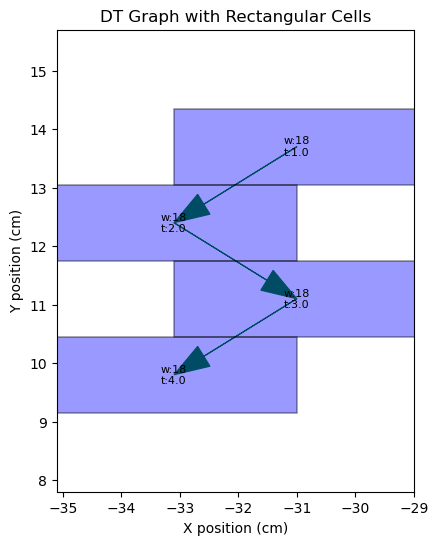

In [51]:
draw_dt_graph_enhanced(graphs[10])

In [52]:
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

def fit_scalers(graphs):
    all_x = torch.cat([g.x for g in graphs], dim=0).numpy()
    all_edge_attr = torch.cat([g.edge_attr for g in graphs if g.edge_attr is not None], dim=0).numpy()
    scaler_x = StandardScaler().fit(all_x)
    scaler_edge = StandardScaler().fit(all_edge_attr)
    return scaler_x, scaler_edge

def normalize_with_scalers(graphs, scaler_x, scaler_edge):
    normalized_graphs = []
    for g in graphs:
        x_norm = torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float)
        
        if g.edge_attr is not None:
            edge_attr_norm = torch.tensor(scaler_edge.transform(g.edge_attr.numpy()), dtype=torch.float)
        else:
            # Si no tiene edge_attr, ponemos un tensor de ceros del tamaño esperado
            edge_index = g.edge_index
            num_edges = edge_index.size(1)
            edge_attr_norm = torch.zeros((num_edges, scaler_edge.mean_.shape[0]), dtype=torch.float)

        g_norm = Data(
            x=x_norm,
            edge_index=g.edge_index,
            y=g.y,
            edge_attr=edge_attr_norm
        )
        normalized_graphs.append(g_norm)
    return normalized_graphs


# 1. Dividir antes de normalizar
train_raw, otros_raw = train_test_split(graphs, test_size=0.2, random_state=42)
validation_raw, test_raw = train_test_split(otros_raw, test_size=0.5, random_state=42)

# 2. Fit de scalers solo con entrenamiento
scaler_x, scaler_edge = fit_scalers(train_raw)

# 3. Aplicar normalización a cada partición
train_dataset = normalize_with_scalers(train_raw, scaler_x, scaler_edge)
validation_dataset = normalize_with_scalers(validation_raw, scaler_x, scaler_edge)
test_dataset = normalize_with_scalers(test_raw, scaler_x, scaler_edge)

# 4. Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=30, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=30, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=30, shuffle=False)



In [53]:
grafo = train_dataset[10]
print("Primer grafo normalizado:")
print(grafo)
print("Nodos segmentos:", grafo.y)
print("Características de los nodos (x):", grafo.x)
print("Índices de las aristas (edge_index):", grafo.edge_index)
print("Atributos de las aristas (edge_attr):", grafo.edge_attr)

Primer grafo normalizado:
Data(x=[8, 6], edge_index=[2, 7], edge_attr=[7, 3], y=[8])
Nodos segmentos: tensor([1, 1, 1, 1, 0, 0, 1, 0])
Características de los nodos (x): tensor([[-1.3197, -0.9236,  0.9229,  1.2081,  1.0970, -0.2830],
        [-0.4236, -0.9236,  0.9819,  1.2391,  0.9874,  1.6147],
        [ 0.4726, -0.9236,  0.9229,  1.2081,  0.8777,  0.1898],
        [ 1.3687, -0.9236,  0.9819,  1.2391,  0.7680, -0.8189],
        [-1.3197,  1.0827,  1.0999,  1.3631, -0.8858,  1.7218],
        [-0.4236,  1.0827,  1.1589,  1.3941, -0.9955, -0.5415],
        [ 0.4726,  1.0827,  1.1589,  1.4251, -1.1052,  0.3916],
        [ 1.3687,  1.0827,  1.1589,  1.3941, -1.2149,  1.1103]])
Índices de las aristas (edge_index): tensor([[0, 1, 2, 4, 5, 6, 3],
        [1, 2, 3, 5, 6, 7, 4]])
Atributos de las aristas (edge_attr): tensor([[ 0.2237,  0.3735, -0.2726],
        [-0.2148,  0.3735, -0.2726],
        [ 0.2237,  0.3735, -0.2726],
        [ 0.2237,  0.3735, -0.2726],
        [ 0.2237,  0.3735, -0.27

In [54]:
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch.nn import Dropout

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_attr_dim, heads=6):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, edge_dim=edge_attr_dim, heads=heads, concat=True)
        self.conv3 = SAGEConv(hidden_channels * heads, hidden_channels)  # Multiplicamos por heads porque concat=True
        self.conv4 = GATConv(hidden_channels, out_channels, edge_dim=edge_attr_dim, heads=1, concat=False)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = self.conv4(x, edge_index, edge_attr)  
        return x  # Para clasificacion binaria

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_attr_dim, heads=6, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, edge_dim=edge_attr_dim, heads=heads, concat=True)
        self.conv3 = SAGEConv(hidden_channels * heads, hidden_channels)  # Multiplicamos por heads porque concat=True
        self.conv4 = GATConv(hidden_channels, out_channels, edge_dim=edge_attr_dim, heads=1, concat=False)

        self.dropout = nn.Dropout(p=dropout)  # Aquí defines la capa de dropout

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv4(x, edge_index, edge_attr)  
        return x

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_attr_dim, heads=2, dropout=0.45):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.norm1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = GATConv(hidden_channels, hidden_channels, edge_dim=edge_attr_dim, heads=heads, concat=True)
        self.norm2 = nn.BatchNorm1d(hidden_channels * heads)

        self.conv3 = SAGEConv(hidden_channels * heads, hidden_channels)
        self.norm3 = nn.BatchNorm1d(hidden_channels)

        self.conv4 = GATConv(hidden_channels, out_channels, edge_dim=edge_attr_dim, heads=1, concat=False)

        self.dropout = nn.Dropout(p=dropout)
        self.res_proj = nn.Linear(hidden_channels * heads, hidden_channels)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        res = x
        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        res = self.res_proj(res)
        x = F.relu(x + res)
        x = self.dropout(x)

        x = self.conv4(x, edge_index, edge_attr)
        return x


# Seleccionar GPU si no esta disponible pues CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')  # 'cuda' o 'cpu'

Device: cpu


In [55]:
from torch import nn
# FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        """
        Focal Loss para clasificación binaria.

        Args:
        - gamma (float): Controla cuánto más duro se penalizan los ejemplos mal clasificados. valores entre 1 y 5
        - alpha (float): Ajusta el peso de las muestras positivas frente a las negativas. valores de 0 a 1
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, preds, targets):
        """
        Calcula la focal loss.
        
        Args:
        - preds: Predicciones del modelo (logits antes de aplicar la función sigmoid).
        - targets: Etiquetas reales binarias (0 para ruido, 1 para segmento).
        
        Returns:
        - Valor de la pérdida.
        """
        preds = preds.view(-1)  # Aplana las predicciones
        targets = targets.view(-1)  # Aplana las etiquetas reales
        
        # Calcula la BCE estándar
        bce_loss = F.binary_cross_entropy_with_logits(preds, targets, reduction="none")
        
        # Calcula la probabilidad de predicción correcta
        pt = torch.exp(-bce_loss)  # pt = P(y=1) para predicciones correctas
        
        # Aplica el peso de la focal loss
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        return focal_loss.mean()

In [71]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, f1_score

# Defino el modelo
# Parametros
input_dim = 6   # x, y positions
hidden_dim = 30 # Dimensiones ocultas
output_dim = 2  # Numero de clases (nodo verdad 1 o no 0)
edge_attr_dim = 3

#model = GCN_2(input_dim, hidden_dim, output_dim, edge_attr_dim)
model = GCN(input_dim, hidden_dim, 1, edge_attr_dim) #output = 1 por el focalloss
lr, weight_decay = 0.001, 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5, verbose=True)

# perdida
#pos_weight = torch.tensor([0.15])  # Ajusta el peso
pos_weight = None
#loss_fn = torch.nn.BCEWithLogitsLoss()
gamma, alpha = 1.75, 0.25
loss_fn = FocalLoss(gamma, alpha)  # Focal Loss con balanceo de clases
#loss_fn = nn.CrossEntropyLoss(weight = class_weights)

def plot_confusion(all_preds,all_labels,epoch):
    # matriz de confusion y el F1-score
    cm = confusion_matrix(all_labels, all_preds)
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"]))

    # Plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion - Epoch {epoch + 1}')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()

def generar_malas_predicciones(preds, labels, malas_predicciones):
    # lista para ver si hay alguna relacion entre las malas predicciones y el nodo 
    for node_idx in range(len(preds)):  
        if preds[node_idx][0] != labels[node_idx][0]:  # Si la prediccion es incorrecta
            malas_predicciones.append({
                'data': data,
                'node_idx': node_idx,
                'nodo': data.x[node_idx],
                'prediccion': preds[node_idx],
                'real_label': labels[node_idx]
            })


threshold = 0.54 #supongo q es 0.5?
def train(data, loss_fn):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)# Forward pass
    loss = loss_fn(out, data.y) # Calcular perdida
    loss.backward()
    optimizer.step()
    preds = out.argmax(dim=1).cpu().numpy()  # Predicciones
    preds =(torch.sigmoid(out) > threshold).float() # lo convierto a float para q no sea true/false
    labels = data.y.cpu().numpy()  # Etiquetas verdaderas
    return loss, preds, labels

def evaluacion(data):
    model.eval()
    data = data.to(device)
    logits = model(data.x, data.edge_index, data.edge_attr)
    loss = loss_fn(logits, data.y)
    preds = torch.argmax(logits, dim=1)
    preds = (torch.sigmoid(logits) > threshold).float()
    return loss, preds, logits


/home/blanca_belmonte/miniconda3/envs/jupyter_ml_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20, Train Loss: 0.0481, Val accuracy: 0.7673, Clase 0 val: Recall : 0.7299, F1-Scores: 0.6498, Clase 1 val: Recall : 0.7152, F1-Scores: 0.7673
Epoch 2/20, Train Loss: 0.0416, Val accuracy: 0.8028, Clase 0 val: Recall : 0.6713, F1-Scores: 0.6554, Clase 1 val: Recall : 0.7920, F1-Scores: 0.8028
Epoch 3/20, Train Loss: 0.0407, Val accuracy: 0.8039, Clase 0 val: Recall : 0.6821, F1-Scores: 0.6612, Clase 1 val: Recall : 0.7899, F1-Scores: 0.8039
Epoch 4/20, Train Loss: 0.0399, Val accuracy: 0.8004, Clase 0 val: Recall : 0.6925, F1-Scores: 0.6624, Clase 1 val: Recall : 0.7804, F1-Scores: 0.8004
Epoch 5/20, Train Loss: 0.0393, Val accuracy: 0.8057, Clase 0 val: Recall : 0.6861, F1-Scores: 0.6647, Clase 1 val: Recall : 0.7914, F1-Scores: 0.8057
Epoch 6/20, Train Loss: 0.0392, Val accuracy: 0.8387, Clase 0 val: Recall : 0.5621, F1-Scores: 0.6426, Clase 1 val: Recall : 0.8966, F1-Scores: 0.8387
Epoch 7/20, Train Loss: 0.0389, Val accuracy: 0.8416, Clase 0 val: Recall : 0.5618, F1-Scores:

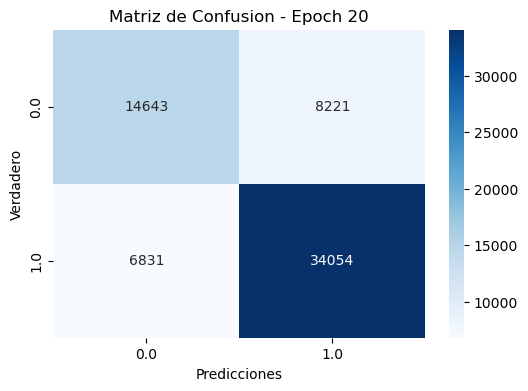

In [72]:
# epocas
epochs = 20

# para hacer las curvas de aprendizaje necesito almacenar las perdidas y precision
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
malas_predicciones=[]

# entrenamiento
for epoch in range(epochs):
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas

    for data in train_loader:
        # Verificar si el grafo tiene aristas
        if data.edge_index.numel() == 0:  
            continue 
        data.y = data.y.float()  
        data.y = data.y.view(-1, 1)  # la salida del modelo es tipo (batch_size, 1), pero data.y tiene forma (batch_size), asi q lo cambio
        loss, preds, labels = train(data, loss_fn)
        epoch_loss += loss.item()
        all_preds.extend(preds)
        all_labels.extend(labels)
        
        # CONFIDENCE SCORE en la ultima epoca
        if epoch == epochs-1:          
            generar_malas_predicciones(preds, labels, malas_predicciones)
    scheduler.step(epoch_loss)
    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds))

    #evaluar modelo
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    with torch.no_grad():
        for data in validation_loader:
            if data.edge_index.numel() == 0:  
                continue 
            data.y = data.y.float()
            data.y = data.y.view(-1, 1) 
            loss, preds, logits = evaluacion(data)
            val_loss += loss.item()
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())  

    val_losses.append(val_loss/len(validation_loader))
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_accuracies.append(f1_score(all_labels_val, all_preds_val))
    
    cr_val = classification_report(all_labels_val, all_preds_val, target_names=["Clase 0", "Clase 1"], output_dict=True)
    recall_clase_0 = cr_val["Clase 0"]["recall"]
    f1_score_clase_0 = cr_val["Clase 0"]["f1-score"]
    precision_clase_0 = cr_val["Clase 0"]["precision"]
    recall_clase_1 = cr_val["Clase 1"]["recall"]
    f1_score_clase_1 = cr_val["Clase 1"]["f1-score"]
    precision_clase_1 = cr_val["Clase 1"]["precision"]
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss/len(train_loader):.4f}, Val accuracy: {f1_score(all_labels_val, all_preds_val):.4f}, Clase 0 val: Recall : {recall_clase_0:.4f}, F1-Scores: {f1_score_clase_0:.4f}, Clase 1 val: Recall : {recall_clase_1:.4f}, F1-Scores: {f1_score_clase_1:.4f}")
    
    # matriz de confusion
    if (epoch+1)%epochs==0:
        plot_confusion(all_preds, all_labels, epoch)


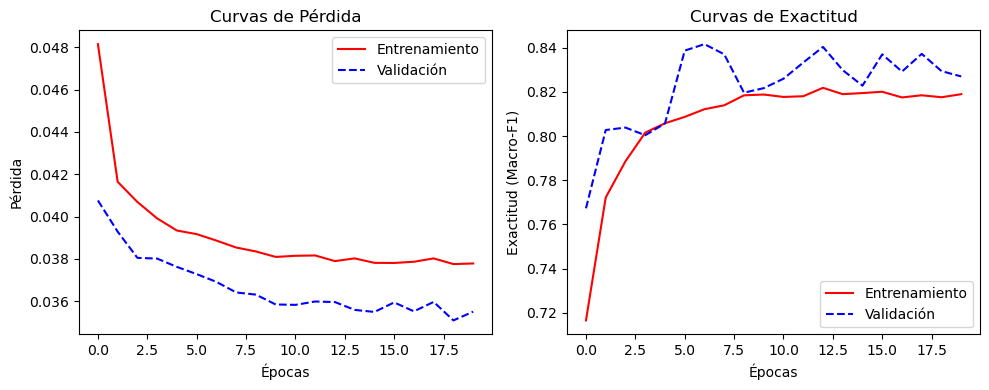

In [77]:
import matplotlib.pyplot as plt

def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Curva de pérdidas
    ax[0].plot(train_losses, 'r-', label='Entrenamiento')
    ax[0].plot(val_losses, 'b--', label='Validación')
    ax[0].set_xlabel('Épocas')
    ax[0].set_ylabel('Pérdida')
    ax[0].set_title('Curvas de Pérdida')
    ax[0].legend()

    # Curva de accuracies (macro-f1 en tu caso)
    ax[1].plot(train_accuracies, 'r-', label='Entrenamiento')
    ax[1].plot(val_accuracies, 'b--', label='Validación')
    ax[1].set_xlabel('Épocas')
    ax[1].set_ylabel('Exactitud (Macro-F1)')
    ax[1].set_title('Curvas de Exactitud')

    ax[1].legend()

    plt.tight_layout()
    plt.show()
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


              precision    recall  f1-score   support

     Clase 0       0.66      0.70      0.68      2722
     Clase 1       0.84      0.81      0.82      5183

    accuracy                           0.77      7905
   macro avg       0.75      0.75      0.75      7905
weighted avg       0.78      0.77      0.77      7905



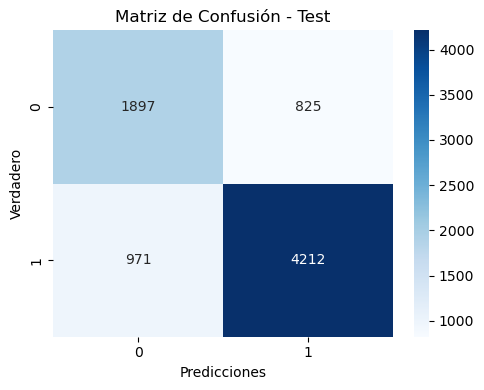

In [81]:
import torch
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluar_modelo(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    errores = []  # Lista para guardar nodos mal clasificados

    with torch.no_grad():
        for i, data in enumerate(dataloader):
            if data.edge_index.numel() == 0:
                continue
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.edge_attr)

            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float().view(-1)
            true_labels = data.y.view(-1)

            all_preds.append(preds.cpu())
            all_labels.append(true_labels.cpu())

            # Detectar nodos mal clasificados
            incorrectos = (preds != true_labels).nonzero(as_tuple=True)[0]
            for idx in incorrectos:
                errores.append({
                    'grafo': data.cpu().clone(),
                    'grafo_id': i,
                    'nodo_id': int(idx),
                    'etiqueta_real': int(true_labels[idx]),
                    'etiqueta_predicha': int(preds[idx])
                })


    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Reporte de clasificación y matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"])
    print(report)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.title('Matriz de Confusión - Test')
    plt.tight_layout()
    plt.show()

    # Convertir errores en un DataFrame para inspección
    df_errores = pd.DataFrame(errores)
    return df_errores

# Uso:
threshold=0.557

df_incorrectos = evaluar_modelo(model, test_loader, device, threshold)
df_incorrectos = df_incorrectos.groupby('grafo_id').agg({
    'grafo': 'first',
    'nodo_id': list,
    'etiqueta_real': list,
    'etiqueta_predicha': list
}).reset_index()




=== alpha=0.25, gamma=1 ===
F1 Clase 0 = 0.6343, F1 Clase 1 = 0.8419

=== alpha=0.25, gamma=2 ===
F1 Clase 0 = 0.6487, F1 Clase 1 = 0.8404

=== alpha=0.25, gamma=3 ===
F1 Clase 0 = 0.6628, F1 Clase 1 = 0.8116

=== alpha=0.25, gamma=4 ===
F1 Clase 0 = 0.6619, F1 Clase 1 = 0.7938

=== alpha=0.25, gamma=5 ===
F1 Clase 0 = 0.6561, F1 Clase 1 = 0.7641

=== alpha=0.5, gamma=1 ===
F1 Clase 0 = 0.6669, F1 Clase 1 = 0.8218

=== alpha=0.5, gamma=2 ===
F1 Clase 0 = 0.6603, F1 Clase 1 = 0.8088

=== alpha=0.5, gamma=3 ===
F1 Clase 0 = 0.6570, F1 Clase 1 = 0.8060

=== alpha=0.5, gamma=4 ===
F1 Clase 0 = 0.6619, F1 Clase 1 = 0.7791

=== alpha=0.5, gamma=5 ===
F1 Clase 0 = 0.6532, F1 Clase 1 = 0.7447

=== alpha=0.75, gamma=1 ===
F1 Clase 0 = 0.6505, F1 Clase 1 = 0.8329

=== alpha=0.75, gamma=2 ===
F1 Clase 0 = 0.6395, F1 Clase 1 = 0.8369

=== alpha=0.75, gamma=3 ===
F1 Clase 0 = 0.6607, F1 Clase 1 = 0.7992

=== alpha=0.75, gamma=4 ===
F1 Clase 0 = 0.6584, F1 Clase 1 = 0.7793

=== alpha=0.75, gamma=5 

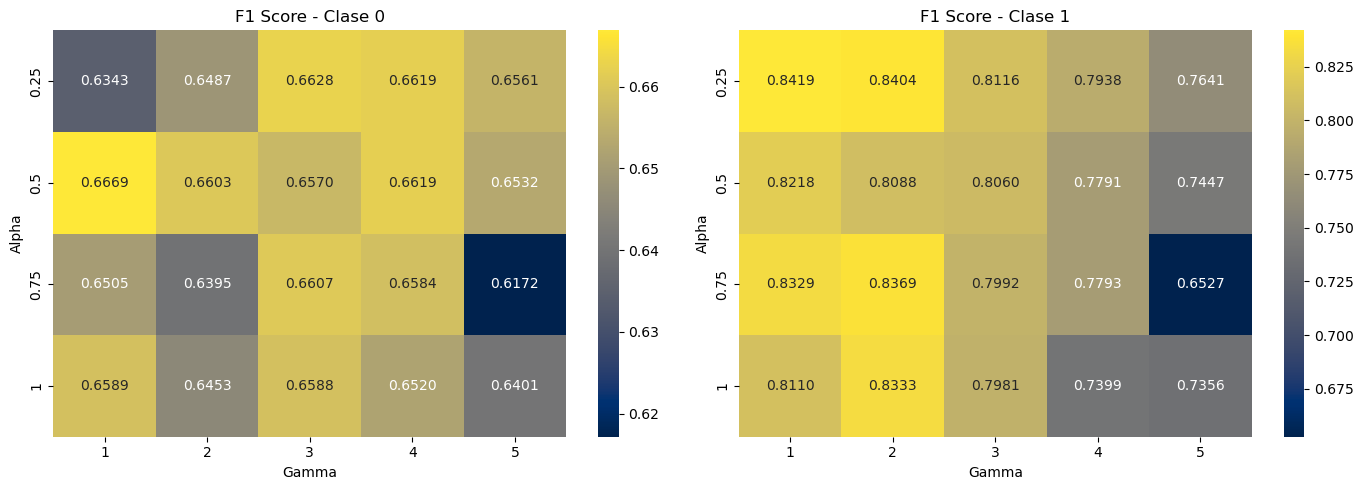

In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import os
import seaborn as sns

# Crear carpeta para guardar modelos
save_folder = "modelos_focal_grid"
os.makedirs(save_folder, exist_ok=True)

# Hiperparámetros
alphas = [0.25, 0.5, 0.75, 1]
gammas = [ 1, 2, 3, 4, 5]

# Resultados por clase
f1_class0 = np.zeros((len(alphas), len(gammas)))
f1_class1 = np.zeros((len(alphas), len(gammas)))

best_macro_f1 = 0.0
best_model_info = None

for i, alpha in enumerate(alphas):
    for j, gamma in enumerate(gammas):
        print(f"\n=== alpha={alpha}, gamma={gamma} ===")

        model = GCN(input_dim, hidden_dim, 1, edge_attr_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = FocalLoss(gamma, alpha)

        for epoch in range(10):  # Menos épocas por grid search
            model.train()
            for data in train_loader:
                if data.edge_index.numel() == 0:
                    continue
                data = data.to(device)
                optimizer.zero_grad()
                out = model(data.x, data.edge_index, data.edge_attr)
                loss = loss_fn(out, data.y.float())
                loss.backward()
                optimizer.step()

        # Evaluar
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for data in validation_loader:
                if data.edge_index.numel() == 0:
                    continue
                data = data.to(device)
                logits = model(data.x, data.edge_index, data.edge_attr)
                preds = (torch.sigmoid(logits) > threshold).float()
                all_preds.append(preds.cpu())
                all_labels.append(data.y.cpu())

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)

        report = classification_report(all_labels.numpy(), all_preds.numpy(), output_dict=True, zero_division=0)
        f1_0 = report['0']['f1-score']
        f1_1 = report['1']['f1-score']
        macro_f1 = report['macro avg']['f1-score']

        f1_class0[i, j] = f1_0
        f1_class1[i, j] = f1_1

        print(f"F1 Clase 0 = {f1_0:.4f}, F1 Clase 1 = {f1_1:.4f}")

        model_name = f"model_alpha{alpha}_gamma{gamma}_macrof1{macro_f1:.4f}.pth"
        torch.save(model.state_dict(), os.path.join(save_folder, model_name))

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_model_info = (model_name, alpha, gamma, macro_f1)

# Mostrar el mejor
print("\n=== Mejor Modelo (macro-F1) ===")
print(f"Path: {best_model_info[0]}")
print(f"alpha: {best_model_info[1]}, gamma: {best_model_info[2]}, Macro-F1: {best_model_info[3]:.4f}")

# --- Visualización doble heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(f1_class0, annot=True, fmt=".4f", cmap='cividis', xticklabels=gammas, yticklabels=alphas, ax=axes[0])
axes[0].set_title("F1 Score - Clase 0")
axes[0].set_xlabel("Gamma")
axes[0].set_ylabel("Alpha")

sns.heatmap(f1_class1, annot=True, fmt=".4f", cmap='cividis', xticklabels=gammas, yticklabels=alphas, ax=axes[1])
axes[1].set_title("F1 Score - Clase 1")
axes[1].set_xlabel("Gamma")
axes[1].set_ylabel("Alpha")

plt.tight_layout()
plt.show()



=== alpha=0.15, gamma=1 ===
F1 Clase 0 = 0.6563, F1 Clase 1 = 0.8496

=== alpha=0.15, gamma=1.5 ===
F1 Clase 0 = 0.6543, F1 Clase 1 = 0.8449

=== alpha=0.15, gamma=1.75 ===
F1 Clase 0 = 0.6409, F1 Clase 1 = 0.8471

=== alpha=0.15, gamma=2 ===
F1 Clase 0 = 0.6722, F1 Clase 1 = 0.8184

=== alpha=0.15, gamma=2.25 ===
F1 Clase 0 = 0.6763, F1 Clase 1 = 0.8237

=== alpha=0.15, gamma=2.5 ===
F1 Clase 0 = 0.6725, F1 Clase 1 = 0.8251

=== alpha=0.25, gamma=1 ===
F1 Clase 0 = 0.6565, F1 Clase 1 = 0.8427

=== alpha=0.25, gamma=1.5 ===
F1 Clase 0 = 0.6393, F1 Clase 1 = 0.8466

=== alpha=0.25, gamma=1.75 ===
F1 Clase 0 = 0.6659, F1 Clase 1 = 0.8443

=== alpha=0.25, gamma=2 ===
F1 Clase 0 = 0.6655, F1 Clase 1 = 0.8349

=== alpha=0.25, gamma=2.25 ===
F1 Clase 0 = 0.6846, F1 Clase 1 = 0.8243

=== alpha=0.25, gamma=2.5 ===
F1 Clase 0 = 0.6833, F1 Clase 1 = 0.8211

=== alpha=0.35, gamma=1 ===
F1 Clase 0 = 0.6530, F1 Clase 1 = 0.8476

=== alpha=0.35, gamma=1.5 ===
F1 Clase 0 = 0.6787, F1 Clase 1 = 0.819

AttributeError: QuadMesh.set() got an unexpected keyword argument 'fontsize'

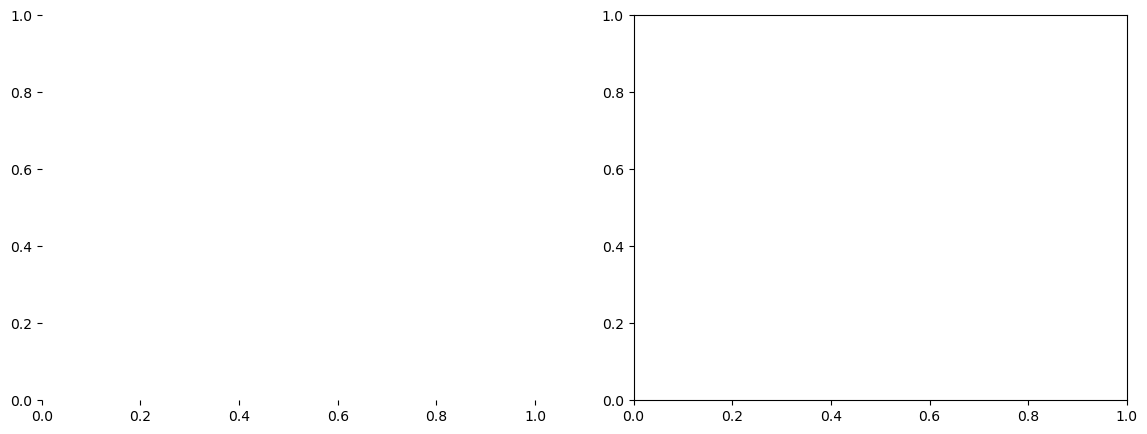

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import os
import seaborn as sns

# Crear carpeta para guardar modelos
save_folder = "modelos_focal_grid"
os.makedirs(save_folder, exist_ok=True)

# Hiperparámetros
alphas = [0.15, 0.25, 0.35, 0.45]
gammas = [ 1, 1.5, 1.75, 2, 2.25, 2.5]

# Resultados por clase
f1_class0 = np.zeros((len(alphas), len(gammas)))
f1_class1 = np.zeros((len(alphas), len(gammas)))

best_macro_f1 = 0.0
best_model_info = None

for i, alpha in enumerate(alphas):
    for j, gamma in enumerate(gammas):
        print(f"\n=== alpha={alpha}, gamma={gamma} ===")

        model = GCN(input_dim, hidden_dim, 1, edge_attr_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = FocalLoss(gamma, alpha)

        for epoch in range(10):  # Menos épocas por grid search
            model.train()
            for data in train_loader:
                if data.edge_index.numel() == 0:
                    continue
                data = data.to(device)
                optimizer.zero_grad()
                out = model(data.x, data.edge_index, data.edge_attr)
                loss = loss_fn(out, data.y.float())
                loss.backward()
                optimizer.step()

        # Evaluar
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for data in validation_loader:
                if data.edge_index.numel() == 0:
                    continue
                data = data.to(device)
                logits = model(data.x, data.edge_index, data.edge_attr)
                preds = (torch.sigmoid(logits) > threshold).float()
                all_preds.append(preds.cpu())
                all_labels.append(data.y.cpu())

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)

        report = classification_report(all_labels.numpy(), all_preds.numpy(), output_dict=True, zero_division=0)
        f1_0 = report['0']['f1-score']
        f1_1 = report['1']['f1-score']
        macro_f1 = report['macro avg']['f1-score']

        f1_class0[i, j] = f1_0
        f1_class1[i, j] = f1_1

        print(f"F1 Clase 0 = {f1_0:.4f}, F1 Clase 1 = {f1_1:.4f}")

        model_name = f"model_alpha{alpha}_gamma{gamma}_macrof1{macro_f1:.4f}.pth"
        torch.save(model.state_dict(), os.path.join(save_folder, model_name))

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_model_info = (model_name, alpha, gamma, macro_f1)

# Mostrar el mejor
print("\n=== Mejor Modelo (macro-F1) ===")
print(f"Path: {best_model_info[0]}")
print(f"alpha: {best_model_info[1]}, gamma: {best_model_info[2]}, Macro-F1: {best_model_info[3]:.4f}")


/tmp/ipykernel_3640/1182102993.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16)


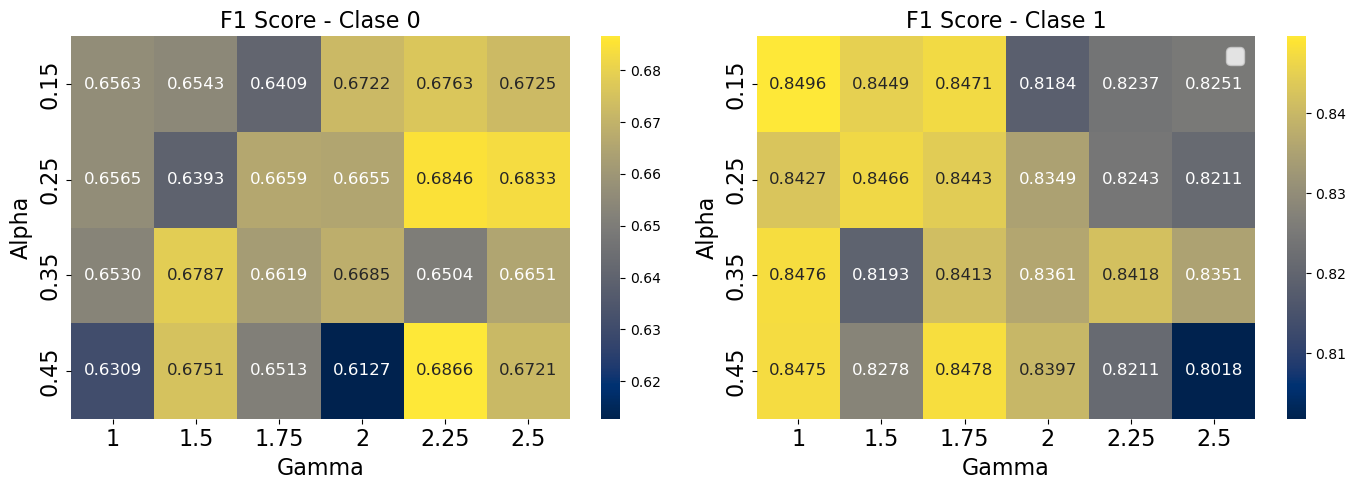

In [ ]:
# --- Visualización doble heatmap con etiquetas visibles ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap para clase 0
sns.heatmap(
    f1_class0,
    annot=True,
    fmt=".4f",
    cmap='cividis',
    xticklabels=gammas,
    yticklabels=alphas,
    annot_kws={"fontsize": 12},  # tamaño de números dentro de los cuadros
    ax=axes[0]
)
axes[0].set_title("F1 Score - Clase 0", fontsize=16)
axes[0].set_xlabel("Gamma", fontsize=16)
axes[0].set_ylabel("Alpha", fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)  # tamaño de los ticks de ejes

# Heatmap para clase 1
sns.heatmap(
    f1_class1,
    annot=True,
    fmt=".4f",
    cmap='cividis',
    xticklabels=gammas,
    yticklabels=alphas,
    annot_kws={"fontsize": 12},
    ax=axes[1]
)
axes[1].set_title("F1 Score - Clase 1", fontsize=16)
axes[1].set_xlabel("Gamma", fontsize=16)
axes[1].set_ylabel("Alpha", fontsize=16)
axes[1].tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()



In [ ]:
import torch
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

def dibujar_grafo(data, nodos_erroneos=None):
    G = to_networkx(data, to_undirected=True)
    pos = {i: (data.x[i][3].item(), data.x[i][4].item()) for i in range(data.num_nodes)}

    plt.figure(figsize=(4, 4))
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color='lightblue')

    if nodos_erroneos is not None:
        if isinstance(nodos_erroneos, int):
            nodos_erroneos = [nodos_erroneos]
        nx.draw_networkx_nodes(G, pos, nodelist=nodos_erroneos, node_color='red', node_size=80)
        nx.draw_networkx_labels(G, pos, labels={i: str(i) for i in nodos_erroneos}, font_size=8, font_color='black')

    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.axis('off')
    plt.show()


'''
for _, fila in df_incoerrectos.iterrows():
    print(f'Grafo ID: {fila["grafo_id"]}, Nodos correctos: {fila["etiqueta_real"]}')
    dibujar_grafo(fila['grafo'], nodos_erroneos=fila['nodo_id'])'''


'\nfor _, fila in df_incoerrectos.iterrows():\n    print(f\'Grafo ID: {fila["grafo_id"]}, Nodos correctos: {fila["etiqueta_real"]}\')\n    dibujar_grafo(fila[\'grafo\'], nodos_erroneos=fila[\'nodo_id\'])'

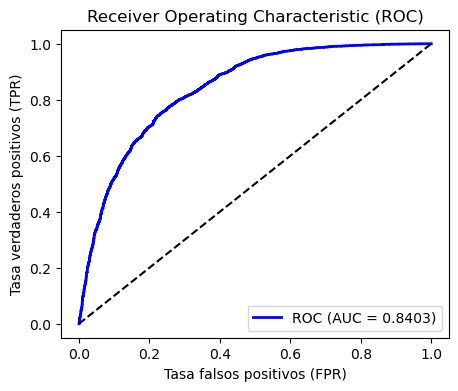

In [66]:
from sklearn.metrics import roc_curve, auc
def probs_labels(model, dataloader, device):
    all_probs = []  # Probabilidades para la clase positiva
    all_labels = []  # Etiquetas verdaderas

    model.eval()
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:  
                continue 
            data.y = data.y.float()
            data.y = data.y.view(-1, 1) 
            out = model(data.x, data.edge_index, data.edge_attr)
            probs = torch.sigmoid(out).cpu().numpy().flatten()  # Correcto para output_dim=1
            labels = data.y.cpu().numpy()

            all_probs.extend(probs.tolist()) 
            all_labels.extend(labels.tolist()) 
    return all_probs, all_labels

def roc_y_auc(all_probs, all_labels):
    FPR, TPR, _ = roc_curve(all_labels, all_probs) #tasa falsos positivos y tasa verdaderos positivos
    roc_auc = auc(FPR, TPR) #area bajo la ROC

    plt.figure(figsize = (5,4))
    plt.plot(FPR, TPR, color ='b', lw=2, label = f'ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Linea diagonal
    plt.xlabel('Tasa falsos positivos (FPR)')
    plt.ylabel('Tasa verdaderos positivos (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

all_probs, all_labels = probs_labels(model, test_loader, device)
roc_y_auc(all_probs, all_labels)